## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Implementing Ridge Regression</p>

Ridge Regression is a regularized version of Linear Regression that uses **L2 regularization**. L2 adds a penalty to large coefficients, helping reduce overfitting and improve model stability without removing any features.

### Why L2 Regularization?

L2 regularization shrinks large coefficients toward zero while keeping all features in the model. It is commonly used when predictor variables are highly correlated (multicollinearity) and helps improve the model's ability to generalize to new data.

## import libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset

In [4]:

df = pd.read_csv("../data/processed/auto_scout_final.csv")
df.shape

(15915, 140)

# Define Features and Target

In [7]:
# X contains the input features.
# y contains the target variable: car price.

X = df.drop("price", axis=1)
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15915, 139)
y shape: (15915,)


# Remove the Rare Audi A2 Feature

In [8]:
# Remove the rare feature that appeared only once
# and caused numerical instability.

if "make_model_Audi A2" in X.columns:
    X = X.drop(columns=["make_model_Audi A2"])
    print("Rare feature removed.")
else:
    print("Rare feature is not present.")

Rare feature removed.


# Split the Dataset

In [11]:
# 80% of the data is used for training.
# 20% is used for testing.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (12732, 138)
Testing features : (3183, 138)
Training target  : (12732,)
Testing target   : (3183,)


# Scale the Features

In [12]:
# Fit the scaler only on the training data
# to prevent data leakage.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the Ridge Model

In [13]:
# alpha controls the strength of L2 regularization.
# Higher alpha values produce stronger coefficient shrinkage.

ridge_model = Ridge(
    alpha=1.0
)

# Train the Model

In [14]:
ridge_model.fit(X_train_scaled, y_train)

Ridge()

# Make Predictions

In [15]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate the Model

In [16]:
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"MAE  : {ridge_mae:.2f}")
print(f"RMSE : {ridge_rmse:.2f}")
print(f"R²   : {ridge_r2:.4f}")

MAE  : 1715.33
RMSE : 2407.50
R²   : 0.8926


In [17]:
print(f"Minimum prediction: {y_pred_ridge.min():.2f}")
print(f"Maximum prediction: {y_pred_ridge.max():.2f}")

Minimum prediction: 729.19
Maximum prediction: 49384.75


# Actual vs Predicted Prices

In [18]:
ridge_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_ridge
})

ridge_results.head(10)

,Actual Price,Predicted Price
12887,26379,25517.364833
8140,18990,18321.575228
6835,12490,11947.162683
15439,32975,34446.949573
1213,15888,14950.531749
13187,15480,14665.453990
1034,20500,21570.893673
2864,16760,16261.330986
7061,18990,17381.374415
14983,27000,23829.741714


# Plot Results

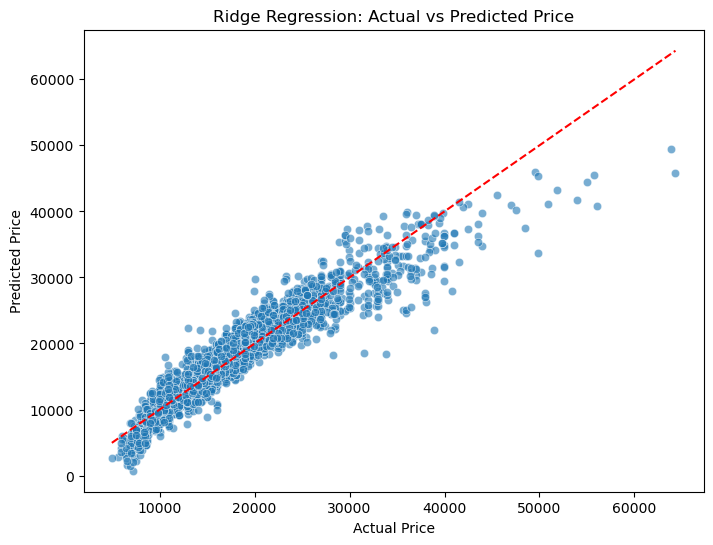

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_ridge,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Actual vs Predicted Price")
plt.show()

# Inspect Coefficients

In [20]:
ridge_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

ridge_coefficients["Absolute"] = ridge_coefficients["Coefficient"].abs()

ridge_coefficients.sort_values(
    "Absolute",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute
2,hp,2632.676188,2632.676188
19,make_model_Renault Clio,-1766.576425,1766.576425
17,make_model_Opel Corsa,-1764.700652,1764.700652
13,year,1675.724061,1675.724061
0,km,-1478.960002,1478.960002
16,make_model_Opel Astra,-1395.568289,1395.568289
35,new_used_Used,-1327.159343,1327.159343
21,make_model_Renault Espace,975.370085,975.370085
32,new_used_Employee's car,-750.908788,750.908788
34,new_used_Pre-registered,-656.387864,656.387864


## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Implementing Lasso Regression</p>

Lasso Regression is a regularized version of Linear Regression that uses **L1 regularization**. L1 can shrink some coefficients to exactly zero, reducing overfitting and automatically selecting the most useful features.

Lasso is useful when the dataset has many features and feature selection is needed.

# Import the Lasso library

In [22]:
from sklearn.linear_model import Lasso

# Create the Lasso Model

In [26]:
# alpha controls the strength of L1 regularization.
# max_iter gives the model enough iterations to converge.

lasso_model = Lasso(
    alpha=0.1,
    max_iter=10000
)

# Train the model

In [28]:
lasso_model.fit(X_train_scaled, y_train)

Lasso(alpha=0.1, max_iter=10000)

# Make Predictions

In [29]:
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Evaluate the Model

In [30]:
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print(f"MAE  : {lasso_mae:.2f}")
print(f"RMSE : {lasso_rmse:.2f}")
print(f"R²   : {lasso_r2:.4f}")

MAE  : 1715.27
RMSE : 2407.44
R²   : 0.8926


# Check Prediction Range

In [31]:
print(f"Minimum prediction: {y_pred_lasso.min():.2f}")
print(f"Maximum prediction: {y_pred_lasso.max():.2f}")

Minimum prediction: 728.06
Maximum prediction: 49387.09


# Actual vs Predicted Prices

In [32]:
lasso_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_lasso
})

lasso_results.head(10)

,Actual Price,Predicted Price
12887,26379,25514.077707
8140,18990,18320.999612
6835,12490,11946.164896
15439,32975,34448.463402
1213,15888,14949.903918
13187,15480,14665.168671
1034,20500,21570.162601
2864,16760,16260.507096
7061,18990,17381.793984
14983,27000,23831.234434


# Plot results 

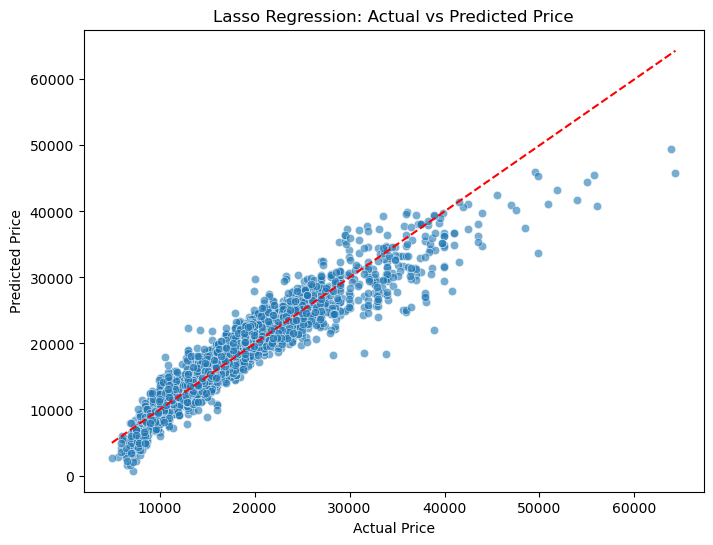

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_lasso,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression: Actual vs Predicted Price")
plt.show()

# Inspect Coefficients

In [34]:
lasso_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

lasso_coefficients["Absolute"] = lasso_coefficients["Coefficient"].abs()

lasso_coefficients.sort_values(
    "Absolute",
    ascending=False
).head(15)

,Feature,Coefficient,Absolute
2,hp,2633.044330,2633.044330
19,make_model_Renault Clio,-1766.597880,1766.597880
17,make_model_Opel Corsa,-1764.604682,1764.604682
13,year,1676.123407,1676.123407
0,km,-1478.886152,1478.886152
16,make_model_Opel Astra,-1395.786209,1395.786209
35,new_used_Used,-1326.804951,1326.804951
21,make_model_Renault Espace,974.858091,974.858091
32,new_used_Employee's car,-750.662521,750.662521
34,new_used_Pre-registered,-656.066495,656.066495


# Count Features

In [35]:
selected_features = np.sum(lasso_model.coef_ != 0)
removed_features = np.sum(lasso_model.coef_ == 0)

print("Selected features:", selected_features)
print("Features reduced to zero:", removed_features)

Selected features: 138
Features reduced to zero: 0


| Model                |         MAE |        RMSE |         R² |
| -------------------- | ----------: | ----------: | ---------: |
| Linear Regression    |     1715.37 |     2407.54 |     0.8926 |
| Ridge Regression     |     1715.33 |     2407.50 |     0.8926 |
| **Lasso Regression** | **1715.27** | **2407.44** | **0.8926** |


### Lasso Regression produced performance nearly identical to Linear and Ridge Regression. Since no coefficients were reduced to zero, Lasso did not perform feature selection with the chosen regularization strength (alpha = 0.1). This suggests that all features contributed to predicting car prices and that a stronger regularization parameter would be required to remove less important features.

# Lasso didnt remove any features because alpha = 0.1 applies only a small amount of L1 regularization.
